# BehaviourSpace Sensitivity Analysis

Notebook for analyzing NetLogo BehaviourSpace **Table output**. It assumes that each row is one simulation run and columns contain model parameters plus output metrics.

The goal is to estimate which input parameters have the strongest influence on selected model results such as total profit, revenue, visits, loyalty cost, lost visits, and customer satisfaction.

## How to use

Place your BehaviourSpace CSV file in the same folder as this notebook or update `DATA_PATH` below. Then run cells from top to bottom.

This notebook does not use numbered section headings, so you can easily insert new sections later.

## Install dependencies

Run this cell only if some packages are missing.

In [14]:
# Uncomment if needed
# %pip install pandas numpy matplotlib scikit-learn statsmodels openpyxl

## Imports

In [15]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Configuration

In [16]:
DATA_PATH = Path("./loyalty-cafes-simple-experiment-table.csv")

# Input parameters from NetLogo BehaviourSpace Table output
PARAMETER_COLUMNS = [
    "satisfaction-purchase-factor",
    "number-of-customers",
    "recommendation-probability",
    "recommendation-boost",
    "base-purchase-probability",
    "mass-market-capacity",
    "premium-capacity",
    "loyalty-effect-multiplier",
    "network-type",
]

# Main KPI to analyze. You can change this later.
TARGET_COLUMN = "sum [profit] of cafes"

# Other useful KPI columns
KPI_COLUMNS = [
    "sum [profit] of cafes",
    "sum [revenue] of cafes",
    "sum [loyalty-cost] of cafes",
    "sum [visits] of cafes",
    "sum [lost-visits] of customers",
    "mean [satisfaction] of customers",
    "[profit] of one-of cafes with [cafe-id = 0]",
    "[profit] of one-of cafes with [cafe-id = 1]",
    "[profit] of one-of cafes with [cafe-id = 2]",
    "[profit] of one-of cafes with [cafe-id = 3]",
    "[profit] of one-of cafes with [cafe-id = 4]",
    "[visits] of one-of cafes with [cafe-id = 0]",
    "[visits] of one-of cafes with [cafe-id = 1]",
    "[visits] of one-of cafes with [cafe-id = 2]",
    "[visits] of one-of cafes with [cafe-id = 3]",
    "[visits] of one-of cafes with [cafe-id = 4]",
]

OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Load BehaviourSpace table output

In [17]:
df = pd.read_csv(DATA_PATH, skiprows=6)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Columns:")
for c in df.columns:
    print("-", c)

df.head()

Shape: (592920, 27)
Columns:
- [run number]
- satisfaction-purchase-factor
- number-of-customers
- recommendation-probability
- recommendation-boost
- base-purchase-probability
- mass-market-capacity
- premium-capacity
- loyalty-effect-multiplier
- network-type
- [step]
- sum [profit] of cafes
- sum [revenue] of cafes
- sum [loyalty-cost] of cafes
- sum [visits] of cafes
- sum [lost-visits] of customers
- mean [satisfaction] of customers
- [profit] of one-of cafes with [cafe-id = 0]
- [profit] of one-of cafes with [cafe-id = 1]
- [profit] of one-of cafes with [cafe-id = 2]
- [profit] of one-of cafes with [cafe-id = 3]
- [profit] of one-of cafes with [cafe-id = 4]
- [visits] of one-of cafes with [cafe-id = 0]
- [visits] of one-of cafes with [cafe-id = 1]
- [visits] of one-of cafes with [cafe-id = 2]
- [visits] of one-of cafes with [cafe-id = 3]
- [visits] of one-of cafes with [cafe-id = 4]


,[run number],satisfaction-purchase-factor,number-of-customers,recommendation-probability,recommendation-boost,base-purchase-probability,mass-market-capacity,premium-capacity,loyalty-effect-multiplier,network-type,[step],sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers,[profit] of one-of cafes with [cafe-id = 0],[profit] of one-of cafes with [cafe-id = 1],[profit] of one-of cafes with [cafe-id = 2],[profit] of one-of cafes with [cafe-id = 3],[profit] of one-of cafes with [cafe-id = 4],[visits] of one-of cafes with [cafe-id = 0],[visits] of one-of cafes with [cafe-id = 1],[visits] of one-of cafes with [cafe-id = 2],[visits] of one-of cafes with [cafe-id = 3],[visits] of one-of cafes with [cafe-id = 4]
0,4,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.754011,0,0.0,0.0,0,0.0,0,0,0,0,0
1,8,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.750246,0,0.0,0.0,0,0.0,0,0,0,0,0
2,2,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.752941,0,0.0,0.0,0,0.0,0,0,0,0,0
3,6,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.751235,0,0.0,0.0,0,0.0,0,0,0,0,0
4,5,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.749274,0,0.0,0.0,0,0.0,0,0,0,0,0


## Validate columns

In [18]:
missing_parameters = [c for c in PARAMETER_COLUMNS if c not in df.columns]
missing_kpis = [c for c in KPI_COLUMNS if c not in df.columns]

if missing_parameters:
    print("Missing parameter columns:")
    for c in missing_parameters:
        print("-", c)
else:
    print("All parameter columns found.")

if missing_kpis:
    print("Missing KPI columns:")
    for c in missing_kpis:
        print("-", c)
else:
    print("All KPI columns found.")

All parameter columns found.
All KPI columns found.


## Basic data cleaning

In [19]:
# Keep only columns that exist in the file
parameter_columns = [c for c in PARAMETER_COLUMNS if c in df.columns]
kpi_columns = [c for c in KPI_COLUMNS if c in df.columns]

# Convert obvious numeric columns to numeric values
for col in parameter_columns + kpi_columns + ["[run number]", "[step]"]:
    if col in df.columns and col != "network-type":
        df[col] = pd.to_numeric(df[col], errors="ignore")

# Drop fully empty columns if any
df = df.dropna(axis=1, how="all")

print("Parameters used:", parameter_columns)
print("KPIs used:", kpi_columns)
df.head()

Parameters used: ['satisfaction-purchase-factor', 'number-of-customers', 'recommendation-probability', 'recommendation-boost', 'base-purchase-probability', 'mass-market-capacity', 'premium-capacity', 'loyalty-effect-multiplier', 'network-type']
KPIs used: ['sum [profit] of cafes', 'sum [revenue] of cafes', 'sum [loyalty-cost] of cafes', 'sum [visits] of cafes', 'sum [lost-visits] of customers', 'mean [satisfaction] of customers', '[profit] of one-of cafes with [cafe-id = 0]', '[profit] of one-of cafes with [cafe-id = 1]', '[profit] of one-of cafes with [cafe-id = 2]', '[profit] of one-of cafes with [cafe-id = 3]', '[profit] of one-of cafes with [cafe-id = 4]', '[visits] of one-of cafes with [cafe-id = 0]', '[visits] of one-of cafes with [cafe-id = 1]', '[visits] of one-of cafes with [cafe-id = 2]', '[visits] of one-of cafes with [cafe-id = 3]', '[visits] of one-of cafes with [cafe-id = 4]']


,[run number],satisfaction-purchase-factor,number-of-customers,recommendation-probability,recommendation-boost,base-purchase-probability,mass-market-capacity,premium-capacity,loyalty-effect-multiplier,network-type,[step],sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers,[profit] of one-of cafes with [cafe-id = 0],[profit] of one-of cafes with [cafe-id = 1],[profit] of one-of cafes with [cafe-id = 2],[profit] of one-of cafes with [cafe-id = 3],[profit] of one-of cafes with [cafe-id = 4],[visits] of one-of cafes with [cafe-id = 0],[visits] of one-of cafes with [cafe-id = 1],[visits] of one-of cafes with [cafe-id = 2],[visits] of one-of cafes with [cafe-id = 3],[visits] of one-of cafes with [cafe-id = 4]
0,4,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.754011,0,0.0,0.0,0,0.0,0,0,0,0,0
1,8,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.750246,0,0.0,0.0,0,0.0,0,0,0,0,0
2,2,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.752941,0,0.0,0.0,0,0.0,0,0,0,0,0
3,6,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.751235,0,0.0,0.0,0,0.0,0,0,0,0,0
4,5,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.749274,0,0.0,0.0,0,0.0,0,0,0,0,0


## Descriptive statistics

In [20]:
df[parameter_columns + kpi_columns].describe(include="all")

,satisfaction-purchase-factor,number-of-customers,recommendation-probability,recommendation-boost,base-purchase-probability,mass-market-capacity,premium-capacity,loyalty-effect-multiplier,network-type,sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers,[profit] of one-of cafes with [cafe-id = 0],[profit] of one-of cafes with [cafe-id = 1],[profit] of one-of cafes with [cafe-id = 2],[profit] of one-of cafes with [cafe-id = 3],[profit] of one-of cafes with [cafe-id = 4],[visits] of one-of cafes with [cafe-id = 0],[visits] of one-of cafes with [cafe-id = 1],[visits] of one-of cafes with [cafe-id = 2],[visits] of one-of cafes with [cafe-id = 3],[visits] of one-of cafes with [cafe-id = 4]
count,5.929200e+05,592920.0,592920.000000,592920.000000,5.929200e+05,592920.0,592920.000000,592920.000000,592920,5.929200e+05,5.929200e+05,5.929200e+05,592920.000000,592920.000000,592920.000000,5.929200e+05,5.929200e+05,5.929200e+05,592920.000000,5.929200e+05,592920.000000,592920.000000,592920.000000,592920.000000,592920.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no network,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.000000e-01,2000.0,0.283333,5.000000,2.000000e-01,500.0,125.000000,1.333333,NaN,2.551631e+06,1.090604e+07,4.846207e+05,318394.905599,19512.515424,0.863819,6.325405e+05,5.017307e+05,5.018718e+05,331747.728294,5.837405e+05,90362.922264,91223.758203,91249.412368,22768.356087,22790.456677
std,5.551120e-17,0.0,0.164992,4.082486,5.551120e-17,0.0,25.000021,0.623610,NaN,1.484808e+06,6.340486e+06,2.883551e+05,184626.798970,19938.524861,0.054777,3.666828e+05,2.904975e+05,2.905496e+05,201896.750970,3.620031e+05,52383.262167,52817.728835,52827.197651,14178.131022,14210.655990
min,2.000000e-01,2000.0,0.100000,0.000000,2.000000e-01,500.0,100.000000,0.500000,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.739565,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000e-01,2000.0,0.100000,0.000000,2.000000e-01,500.0,100.000000,0.500000,NaN,1.271485e+06,5.414320e+06,2.363884e+05,158128.500000,2939.000000,0.811883,3.150000e+05,2.502500e+05,2.502500e+05,163260.000000,2.806342e+05,45000.000000,45500.000000,45500.000000,10900.000000,10900.000000
50%,2.000000e-01,2000.0,0.250000,5.000000,2.000000e-01,500.0,125.000000,1.500000,NaN,2.539305e+06,1.087636e+07,4.807371e+05,317900.000000,13288.000000,0.875937,6.320510e+05,5.005000e+05,5.017348e+05,318825.000000,5.605036e+05,90293.000000,91000.000000,91224.500000,21900.000000,21900.000000
75%,2.000000e-01,2000.0,0.500000,10.000000,2.000000e-01,500.0,150.000000,2.000000,NaN,3.807196e+06,1.633914e+07,7.251005e+05,477700.000000,29012.000000,0.913653,9.486610e+05,7.535000e+05,7.535000e+05,474396.250000,8.403730e+05,135523.000000,137000.000000,137000.000000,32850.000000,32850.000000


## KPI distributions

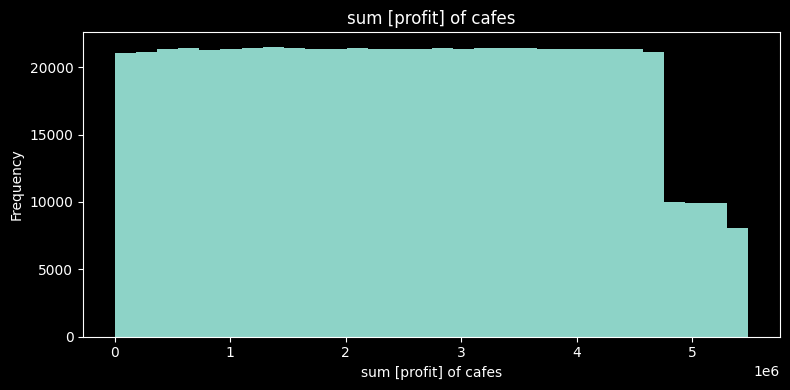

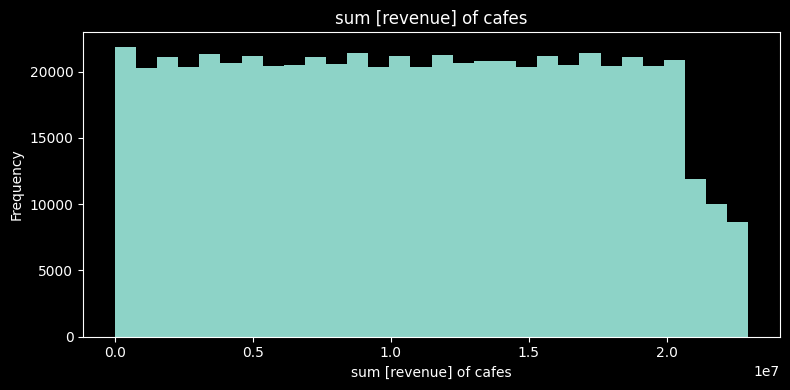

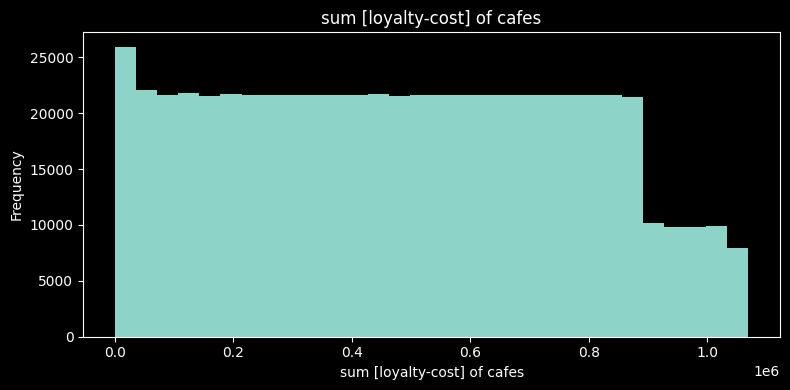

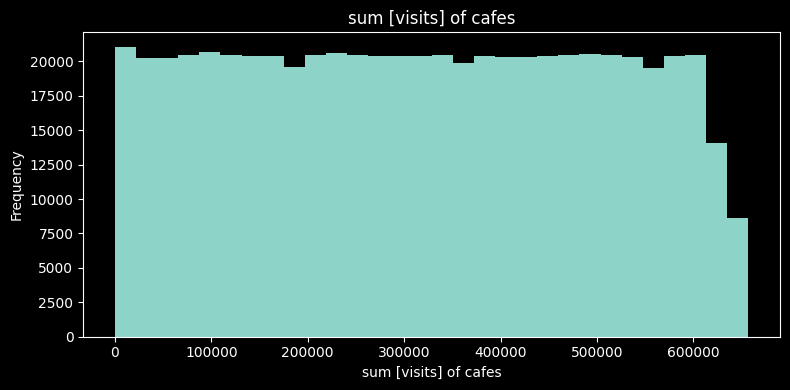

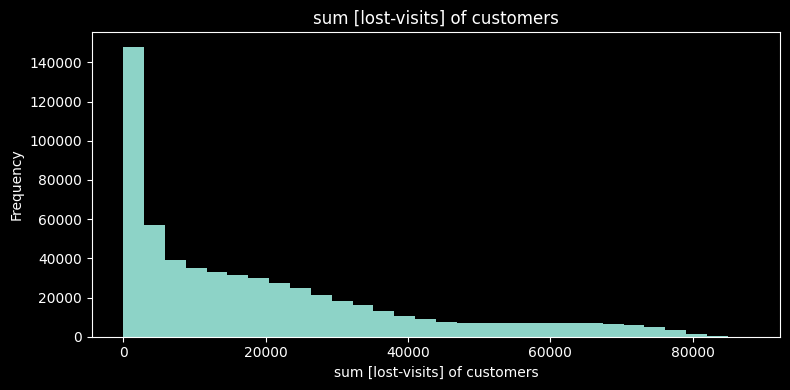

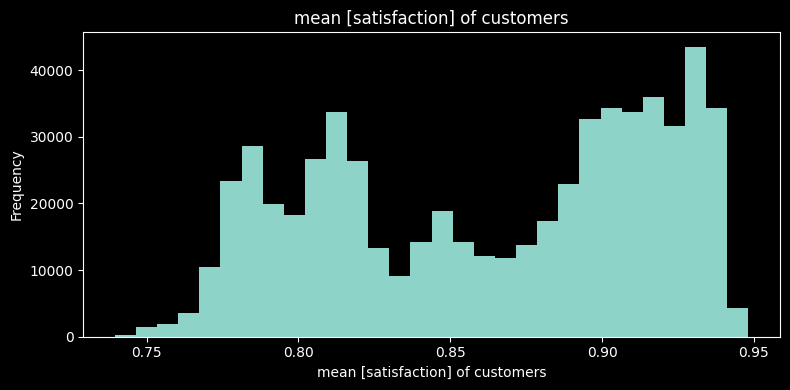

In [21]:
for col in kpi_columns[:6]:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Grouped summaries by network type

In [22]:
if "network-type" in df.columns:
    summary_by_network = df.groupby("network-type")[kpi_columns[:6]].agg(["mean", "std", "min", "max"])
    display(summary_by_network)
else:
    print("Column 'network-type' not found.")

sum [profit] of cafes                                  sum [revenue] of cafes                             sum [loyalty-cost] of cafes                                 \
                                         mean           std  min           max                   mean           std min       max                        mean            std  min        max   
network-type                                                                                                                                                                                   
no network                       2.551675e+06  1.484747e+06  0.0  5.483297e+06           1.090614e+07  6.340394e+06   0  22957945               484778.409885  288495.589833  0.0  1069591.9   
preferential attachment          2.551729e+06  1.484964e+06  0.0  5.483113e+06           1.090659e+07  6.340923e+06   0  22961935               484565.250642  288287.177015  0.0  1068083.9   
small world                      2.551490e+06  1.484719e+06  0.0  5.484075e+06           1.090539e+07  6.340172e+06   0  22963795               484518.574527  288283.814998  0.0  1068774.1   

                        sum [visits] of cafes                            sum [lost-visits] of customers                          mean [satisfaction] of customers                                
                                         mean            std min     max                           mean           std min    max                             mean       std       min       max  
network-type                                                                                                                                                                                     
no network                      318374.939359  184611.493773   0  656955                   19394.246261  19862.285708   0  87890                         0.862181  0.055772  0.741678  0.947999  
preferential attachment         318423.507245  184644.386698   0  656970                   19558.206557  19947.445535   0  86410                         0.864709  0.054373  0.739565  0.947441  
small world                     318386.270193  184625.445627   0  656976                   19585.093453  20005.149936   0  87644                         0.864566  0.054137  0.741120  0.948154

## Single-parameter sensitivity plots

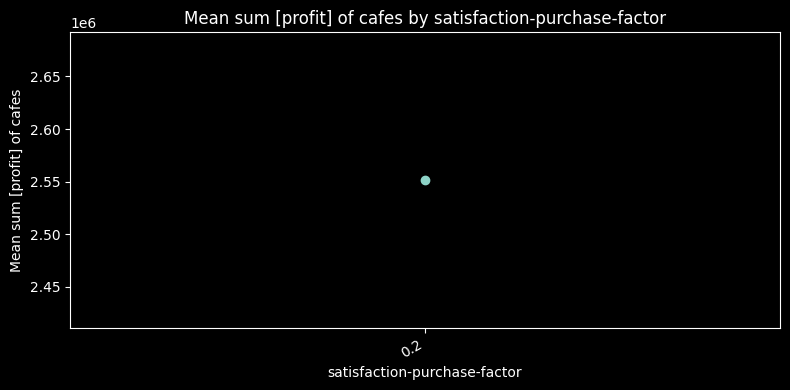

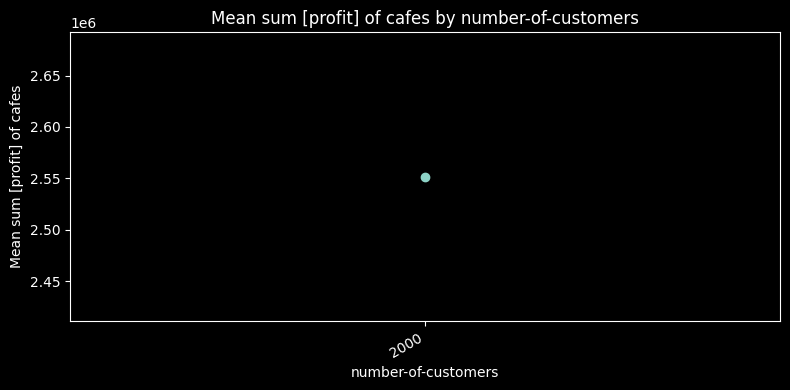

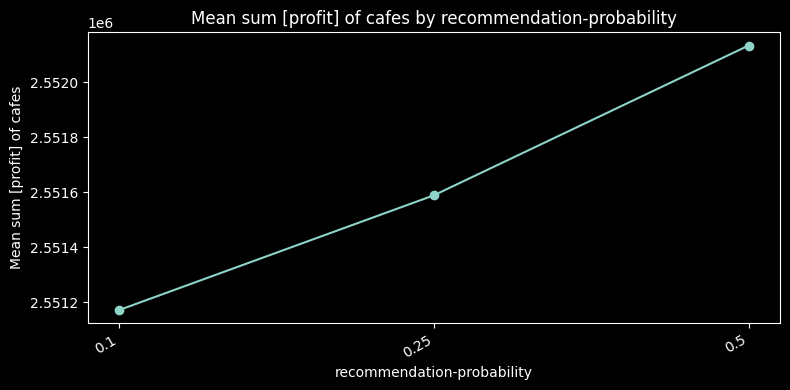

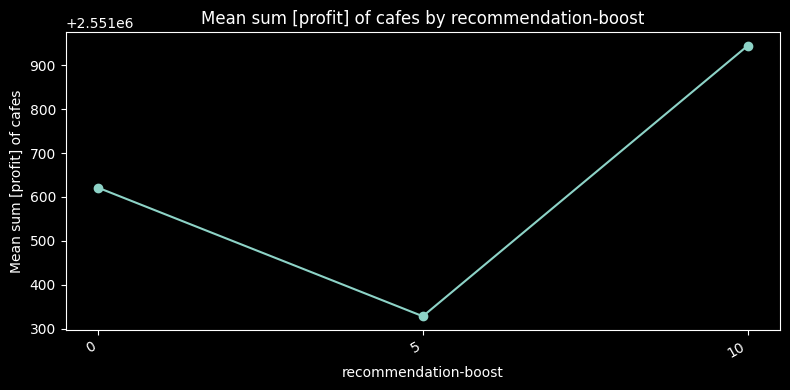

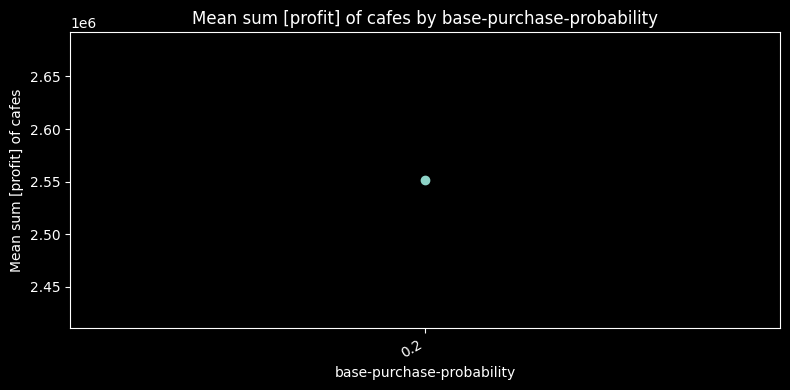

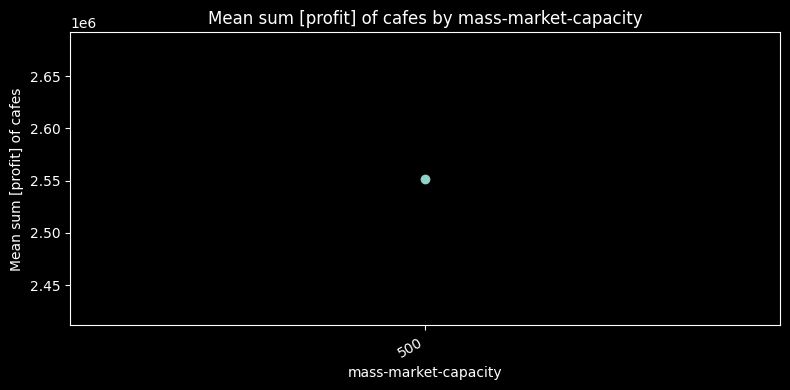

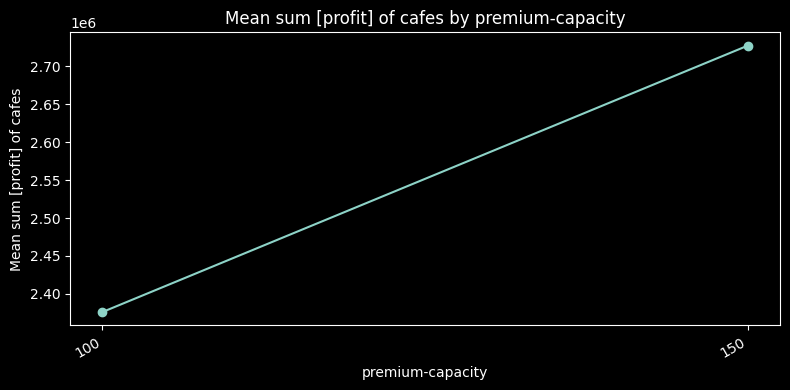

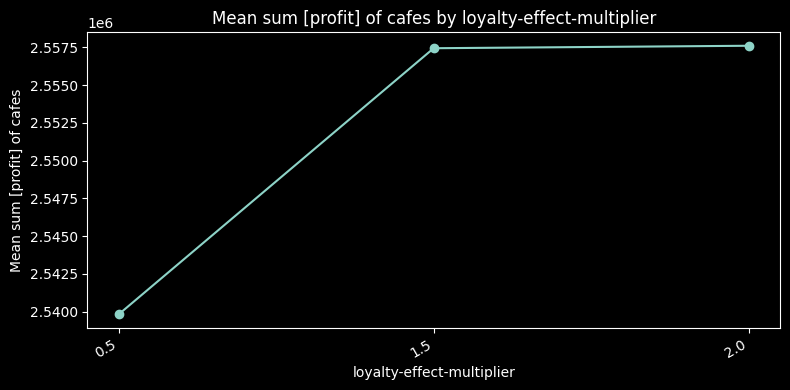

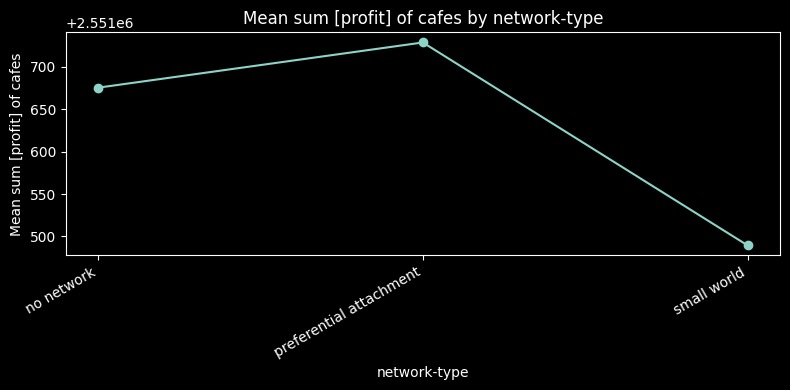

In [23]:
def plot_mean_by_parameter(data, parameter, target):
    summary = data.groupby(parameter)[target].mean().reset_index()
    summary = summary.sort_values(parameter)

    plt.figure(figsize=(8, 4))
    plt.plot(summary[parameter].astype(str), summary[target], marker="o")
    plt.title(f"Mean {target} by {parameter}")
    plt.xlabel(parameter)
    plt.ylabel(f"Mean {target}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

for parameter in parameter_columns:
    plot_mean_by_parameter(df, parameter, TARGET_COLUMN)

## Prepare data for machine learning

In [24]:
analysis_df = df[parameter_columns + [TARGET_COLUMN]].dropna().copy()

X = analysis_df[parameter_columns]
y = analysis_df[TARGET_COLUMN]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Target:", TARGET_COLUMN)

Categorical features: ['network-type']
Numeric features: ['satisfaction-purchase-factor', 'number-of-customers', 'recommendation-probability', 'recommendation-boost', 'base-purchase-probability', 'mass-market-capacity', 'premium-capacity', 'loyalty-effect-multiplier']
Target: sum [profit] of cafes


## Random Forest model quality

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print("R²:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))

R²: 0.014
MAE: 1271888.8617


## Permutation importance

In [34]:
perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "parameter": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df

,parameter,importance_mean,importance_std
6,premium-capacity,0.028213,0.000646
0,satisfaction-purchase-factor,0.000000,0.000000
1,number-of-customers,0.000000,0.000000
4,base-purchase-probability,0.000000,0.000000
5,mass-market-capacity,0.000000,0.000000
7,loyalty-effect-multiplier,-0.000254,0.000053
8,network-type,-0.000364,0.000045
3,recommendation-boost,-0.000410,0.000043
2,recommendation-probability,-0.000418,0.000042


## Plot parameter importance

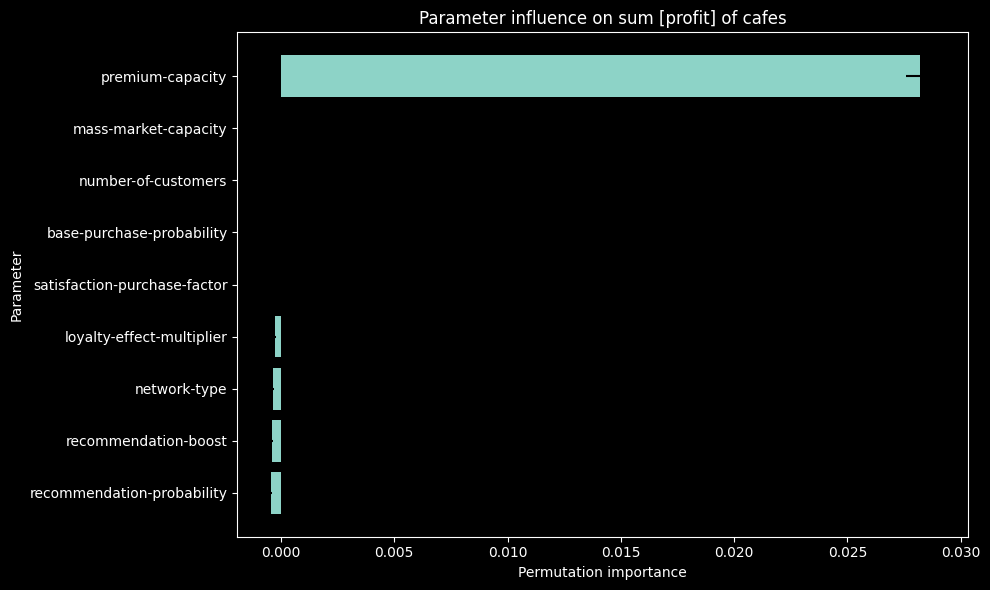

In [27]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["parameter"], importance_df["importance_mean"], xerr=importance_df["importance_std"])
plt.xlabel("Permutation importance")
plt.ylabel("Parameter")
plt.title(f"Parameter influence on {TARGET_COLUMN}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "parameter_importance.png", dpi=200)
plt.show()

## Standardized linear regression

In [28]:
# One-hot encode categorical variables and standardize numeric variables.
# This helps compare coefficient magnitudes.

encoded = pd.get_dummies(analysis_df[parameter_columns], drop_first=True)
encoded = encoded.apply(pd.to_numeric, errors="coerce")

X_encoded = encoded.dropna(axis=1, how="all")
valid_rows = X_encoded.notna().all(axis=1) & y.notna()

X_encoded = X_encoded.loc[valid_rows]
y_valid = y.loc[valid_rows]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_encoded)
y_scaled = scaler_y.fit_transform(y_valid.to_numpy().reshape(-1, 1)).ravel()

lin_model = LinearRegression()
lin_model.fit(X_scaled, y_scaled)

coef_df = pd.DataFrame({
    "parameter": X_encoded.columns,
    "standardized_coefficient": lin_model.coef_,
    "absolute_effect": np.abs(lin_model.coef_),
}).sort_values("absolute_effect", ascending=False)

coef_df

,parameter,standardized_coefficient,absolute_effect
6,premium-capacity,1.182442e-01,1.182442e-01
7,loyalty-effect-multiplier,5.320428e-03,5.320428e-03
2,recommendation-probability,2.646471e-04,2.646471e-04
3,recommendation-boost,8.882354e-05,8.882354e-05
9,network-type_small world,-5.896298e-05,5.896298e-05
8,network-type_preferential attachment,1.690583e-05,1.690583e-05
4,base-purchase-probability,5.204170e-18,5.204170e-18
5,mass-market-capacity,-4.624800e-18,4.624800e-18
0,satisfaction-purchase-factor,0.000000e+00,0.000000e+00
1,number-of-customers,0.000000e+00,0.000000e+00


## Plot standardized coefficients

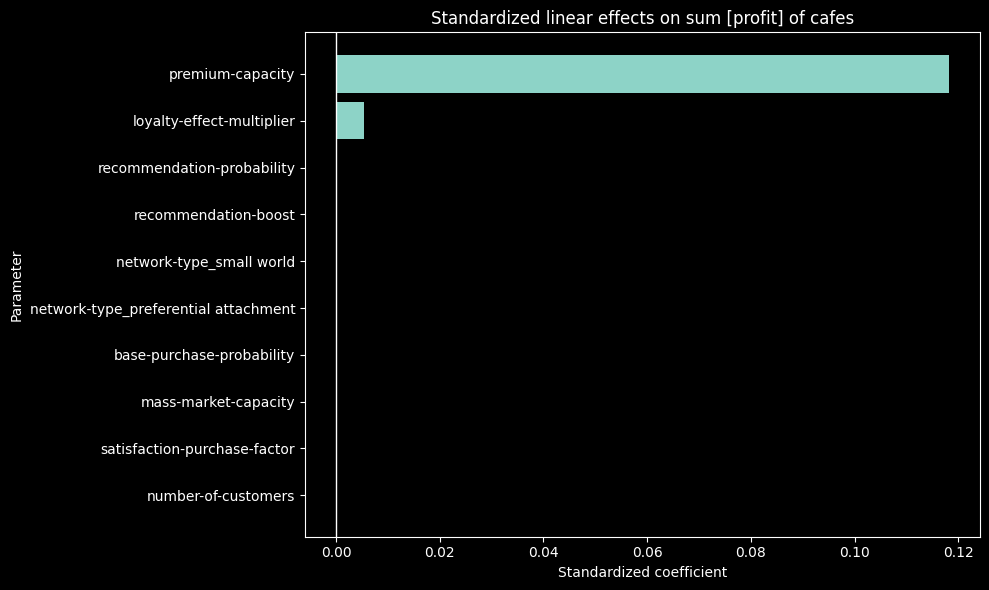

In [29]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df["parameter"], coef_df["standardized_coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("Parameter")
plt.title(f"Standardized linear effects on {TARGET_COLUMN}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "standardized_coefficients.png", dpi=200)
plt.show()

## OLS regression with p-values

In [30]:
def make_safe_column_name(name):
    safe = re.sub(r"[^0-9a-zA-Z_]+", "_", name)
    safe = safe.strip("_")
    if re.match(r"^\d", safe):
        safe = "x_" + safe
    return safe

safe_df = analysis_df.copy()
rename_map = {col: make_safe_column_name(col) for col in safe_df.columns}
safe_df = safe_df.rename(columns=rename_map)

safe_target = rename_map[TARGET_COLUMN]
safe_parameters = [rename_map[c] for c in parameter_columns]

terms = []
for original, safe in zip(parameter_columns, safe_parameters):
    if original in categorical_features:
        terms.append(f"C({safe})")
    else:
        terms.append(safe)

formula = safe_target + " ~ " + " + ".join(terms)
print(formula)

ols_model = smf.ols(formula=formula, data=safe_df).fit()
print(ols_model.summary())

sum_profit_of_cafes ~ satisfaction_purchase_factor + number_of_customers + recommendation_probability + recommendation_boost + base_purchase_probability + mass_market_capacity + premium_capacity + loyalty_effect_multiplier + C(network_type)
                             OLS Regression Results                            
Dep. Variable:     sum_profit_of_cafes   R-squared:                       0.014
Model:                             OLS   Adj. R-squared:                  0.014
Method:                  Least Squares   F-statistic:                     1404.
Date:                 Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                         19:19:31   Log-Likelihood:            -9.2630e+06
No. Observations:               592920   AIC:                         1.853e+07
Df Residuals:                   592913   BIC:                         1.853e+07
Df Model:                            6                                         
Covariance Type:             nonrobust 

## Sensitivity across multiple KPI targets

In [31]:
def compute_permutation_importance_for_target(data, parameters, target):
    local_df = data[parameters + [target]].dropna().copy()
    X_local = local_df[parameters]
    y_local = local_df[target]

    categorical = X_local.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric = [c for c in X_local.columns if c not in categorical]

    pre = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
            ("num", "passthrough", numeric),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )

    pipe = Pipeline([("preprocessor", pre), ("model", model)])

    X_tr, X_te, y_tr, y_te = train_test_split(X_local, y_local, test_size=0.25, random_state=42)
    pipe.fit(X_tr, y_tr)

    perm = permutation_importance(pipe, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)

    result = pd.DataFrame({
        "target": target,
        "parameter": X_local.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
        "r2": r2_score(y_te, pipe.predict(X_te)),
    })
    return result

all_importances = []
for target in kpi_columns[:6]:
    all_importances.append(compute_permutation_importance_for_target(df, parameter_columns, target))

all_importances_df = pd.concat(all_importances, ignore_index=True)
all_importances_df.sort_values(["target", "importance_mean"], ascending=[True, False]).head(30)

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/joblib_memmapping_folder_35050_9b454af5f53144da94f164bead5040cf_c31e6505d288484bb877924b7ce87fae for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/joblib_memmapping_folder_35050_f35d29607255401e8fe9a161

,target,parameter,importance_mean,importance_std,r2
52,mean [satisfaction] of customers,loyalty-effect-multiplier,1.379146e+00,3.426882e-03,0.777101
51,mean [satisfaction] of customers,premium-capacity,1.728325e-01,5.463480e-04,0.777101
48,mean [satisfaction] of customers,recommendation-boost,3.043154e-03,5.426631e-05,0.777101
53,mean [satisfaction] of customers,network-type,2.675678e-03,6.806413e-05,0.777101
47,mean [satisfaction] of customers,recommendation-probability,9.238234e-04,3.729280e-05,0.777101
45,mean [satisfaction] of customers,satisfaction-purchase-factor,0.000000e+00,0.000000e+00,0.777101
46,mean [satisfaction] of customers,number-of-customers,0.000000e+00,0.000000e+00,0.777101
49,mean [satisfaction] of customers,base-purchase-probability,0.000000e+00,0.000000e+00,0.777101
50,mean [satisfaction] of customers,mass-market-capacity,0.000000e+00,0.000000e+00,0.777101
42,sum [lost-visits] of customers,premium-capacity,6.612853e-01,2.095810e-03,0.428726


## Export summary tables

In [32]:
importance_df.to_csv(OUTPUT_DIR / "parameter_importance_main_target.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "standardized_coefficients_main_target.csv", index=False)
all_importances_df.to_csv(OUTPUT_DIR / "parameter_importance_all_targets.csv", index=False)

print("Saved files to:", OUTPUT_DIR.resolve())

Saved files to: /Users/igor/projects/phd/loyalty-agent-model/analysis_outputs


## Interpretation notes

Use the results carefully:

- **Permutation importance** shows how much model accuracy drops when a parameter is randomly shuffled. Higher values mean stronger influence on the selected KPI.
- **Standardized coefficients** show approximate linear direction and strength. Positive values increase the KPI; negative values decrease it.
- **OLS p-values** are useful for reporting, but they depend on assumptions of linear regression and may be less reliable if relationships are nonlinear.
- For a stochastic NetLogo model, use multiple repetitions per parameter combination and analyze mean values or include run-level variation in the interpretation.